In [2]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
from scipy import  stats
from statsmodels.graphics.tsaplots import plot_acf


1. Research question
2. Markov-chain simulation
3. Transition-matrix estimation
4. Stationary distribution
5. Regime durations
6. Convergence experiment
7. Markov-switching return generator
8. Synthetic diagnostics
9. SPY–synthetic comparison
10. Sensitivity experiment
11. Conclusion

14. Sonuç paragrafında cevaplayacağın sorular

Kendi sonuçlarına göre şunları yaz:

Model raw-return ACF’sinin düşük olmasını üretti mi?
Absolute-return ACF’sinde pozitif kalıcılık üretti mi?
Pozitif excess kurtosis üretti mi?
SPY’ın 9.48 kurtosis değerine ulaştı mı?
Sentetik volatilite hafızası SPY’dan daha kısa mı?
Hangi parametre hangi özelliği değiştirdi?
Model neden henüz gerçek SPY modeli olarak kabul edilemez?

ilk hafta volatilite kümelenmesi olduğu görüldü ve getirinin bir tane normal dağılımdan değil 2 tane  biri yüksek varyanslı biri küçük varyanslı olacak şekilde iç içe geçmiş dağılımdan gelmiş olabileceği varsayıldı

Gösterebilir:
İki durumlu mekanizma bu istatistikleri üretebiliyor.

Başta bir bir transation matris bulucam ondan sonrasında ona 1 0 dizisi ürettirip sentetikle test ediyoruz

In [3]:
P_matrice = np.array([[0.95, 0.05],
              [0.20, 0.80]])
#0 : low volatility
#1 : high volatility

rng = np.random.default_rng(seed = 94)

def simulate_chain(P,n,s0,rng):
    states = np.zeros(n, dtype = int)
    states[0] = s0
    number_of_states = P.shape[0] # satir sayisi
    for i in range(1,n):
        current_state = states[i-1]
        transition_probs = P[current_state]
        states[i] = rng.choice(number_of_states, p = transition_probs)

    return states

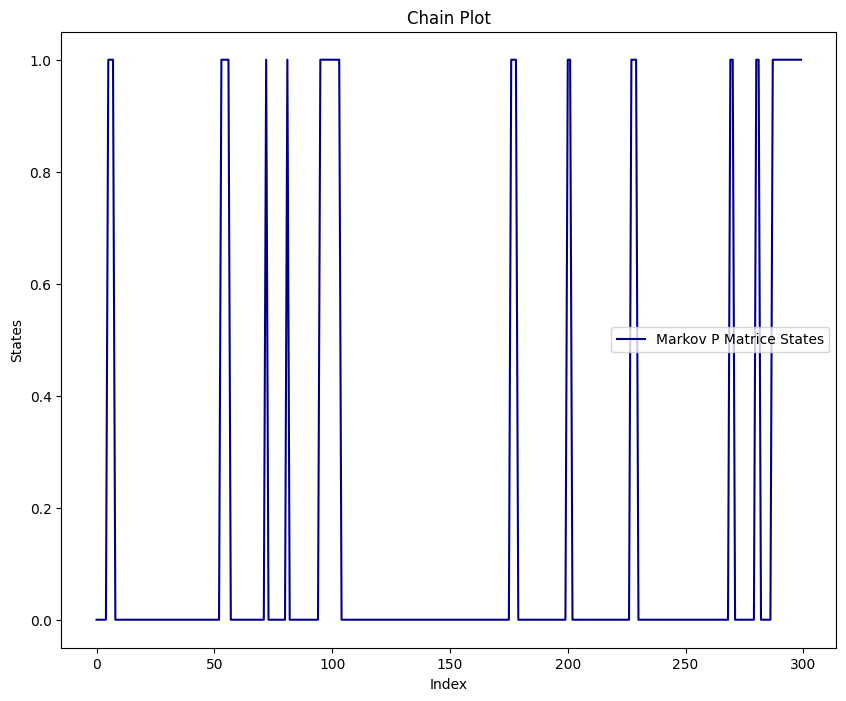

{0: 3883, 1: 1117}


In [27]:
state_chain = simulate_chain(P_matrice, 5000, 0, rng)

plt.figure(figsize=(10,8))
plt.plot(range(300), state_chain[:300], label = "Markov P Matrice States", color = "darkblue")
plt.title("Chain Plot")
plt.xlabel("Index")
plt.ylabel("States")
plt.legend()
plt.show()
states, counts = np.unique(state_chain, return_counts=True)
count_result = dict(zip(states.tolist(), counts.tolist()))
print(count_result)

In [31]:
today = state_chain[:-1]
tomorrow = state_chain[1:]
N00 = np.sum((today == 0 ) & (tomorrow==0 ))
N01 = np.sum((today == 0 ) & (tomorrow == 1))
N10 = np.sum((today == 1) & (tomorrow == 0))
N11 = np.sum((today == 1 ) & (tomorrow == 1))

N_matrice = np.array([[N00,N01],
                      [N10,N11]])
print(f"Calculated Matrice:\n {N_matrice}")

sum_of_rows = N_matrice.sum(axis=1,keepdims=True)
P_hat = N_matrice / sum_of_rows

print("\nReal P:\n", P_matrice)
print("\nEstimated P-hat:\n", P_hat)
print("\nDifferance (P-hat - P):\n", P_hat - P_matrice)

Calculated Matrice:
 [[3669  214]
 [ 213  903]]

Real P:
 [[0.95 0.05]
 [0.2  0.8 ]]

Estimated P-hat:
 [[0.94488797 0.05511203]
 [0.19086022 0.80913978]]

Differance (P-hat - P):
 [[-0.00511203  0.00511203]
 [-0.00913978  0.00913978]]


In [6]:
#Stationary Distributionu bulma

# sQ = s

n = P_matrice.shape[0]

A = P_matrice.T - np.eye(n)

b = np.zeros(n)

A[-1, :] = 1  #normalize ediliyor
b[-1] = 1

s = np.linalg.solve(A,b)

print("Stationary distribution:", s)
print("sQ:", s @ P_matrice)
print("sQ = s :", np.allclose(s @ P_matrice, s))

Stationary distribution: [0.8 0.2]
sQ: [0.8 0.2]
sQ = s : True


In [ ]:
#Ortalama Rejim kalım süresi geometrik hesaplanır çünkü mantıken düşündüğümüzde rejimin bir duruma gelmesi geometrik dağılır 0. rejimdeysek 1 e geçme olasılıgımız kaç denenin sonunda geçtiğimiz geometrik dağılımın sorusudur.
#X ~ Geom(p) ise E(X) = 1/1-pii dir proof omitted. pii - > rejimde kalma , 1-pii rejimdden cıkma 
#Markov swithchinge göre  memoryless bir yapı var olasılık gerçekten sahip mi yoksa rejimde durdurkça değişiyor mu 

# Model-implied durations using the true transition matrix
theoretical_low_duration = 1 / (1 - P_matrice[0, 0])
theoretical_high_duration = 1 / (1 - P_matrice[1, 1])

# Empirical durations using transition counts
empirical_low_duration = (N00 + N01) / N01
empirical_high_duration = (N10 + N11) / N10

# Durations implied by the estimated transition matrix
estimated_low_duration = 1 / (1 - P_hat[0, 0])
estimated_high_duration = 1 / (1 - P_hat[1, 1])

print("\n--- REGIME DURATIONS ---")

print(f"Theoretical low-vol duration : {theoretical_low_duration:.4f}")
print(f"Empirical low-vol duration   : {empirical_low_duration:.4f}")
print(f"P-hat low-vol duration       : {estimated_low_duration:.4f}")

print("-" * 45)

print(f"Theoretical high-vol duration: {theoretical_high_duration:.4f}")
print(f"Empirical high-vol duration  : {empirical_high_duration:.4f}")
print(f"P-hat high-vol duration      : {estimated_high_duration:.4f}")

Average high volatility regime duration : 5.000000000000001
Average low volatility regime duration: 19.999999999999982
